In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print("⚠️  No GPU detected. Switch runtime to T4 GPU before continuing.")

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
!pip install -q transformers torchaudio scikit-learn matplotlib seaborn tqdm

In [3]:
import os

if not os.path.exists("ravdess"):
    !wget -q https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip
    !unzip -q Audio_Speech_Actors_01-24.zip -d ravdess
    !rm Audio_Speech_Actors_01-24.zip
    print("Download and unzip complete.")
else:
    print("ravdess/ already exists, skipping download.")

# Sanity check
import glob
wav_files = glob.glob("ravdess/**/*.wav", recursive=True)
print(f"Found {len(wav_files)} .wav files (expected: 1440)")

Download and unzip complete.
Found 1440 .wav files (expected: 1440)


In [4]:
import torch

# ── Paths ───────────────────────────────────────────────────
DATA_DIR         = "./ravdess"
EMBEDDINGS_CACHE = "./cache/embeddings.pt"
CHECKPOINTS_DIR  = "./checkpoints"
RESULTS_DIR      = "./results"

# ── Model ───────────────────────────────────────────────────
PRETRAINED_MODEL = "facebook/wav2vec2-base"   # 95M params, 768-dim hidden
HIDDEN_DIM       = 768
NUM_CLASSES      = 8                          # All 8 RAVDESS emotions

# ── Audio processing ────────────────────────────────────────
SAMPLE_RATE        = 16000                    # Wav2Vec2 expects 16 kHz mono
MAX_AUDIO_SECONDS  = 4.0
MAX_AUDIO_SAMPLES  = int(SAMPLE_RATE * MAX_AUDIO_SECONDS)

# ── Speaker-independent splits ──────────────────────────────
TRAIN_ACTORS = list(range(1, 19))             # Actors 1-18  (~1080 clips)
VAL_ACTORS   = [19, 20, 21]                   # Actors 19-21 (~180 clips)
TEST_ACTORS  = [22, 23, 24]                   # Actors 22-24 (~180 clips)

# ── Frozen-condition training ───────────────────────────────
FROZEN_BATCH_SIZE   = 64
FROZEN_LR           = 1e-3
FROZEN_WEIGHT_DECAY = 0.01
FROZEN_EPOCHS       = 100
FROZEN_PATIENCE     = 15

# ── Fine-tune-condition training ────────────────────────────
FT_BATCH_SIZE             = 8
FT_HEAD_LR                = 1e-3              # Larger LR for fresh head
FT_ENCODER_LR             = 5e-5              # Smaller LR for pretrained encoder
FT_WEIGHT_DECAY           = 0.01
FT_EPOCHS                 = 15
FT_PATIENCE               = 4
FT_WARMUP_RATIO           = 0.1               # Linear warmup for first 10% of steps
FT_FREEZE_FEATURE_ENCODER = True              # Freeze CNN front-end (standard practice)
FT_GRAD_CLIP              = 1.0

# ── Reproducibility & device ────────────────────────────────
SEED   = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Emotion label mapping (RAVDESS filename code -> label) ──
EMOTION_MAP = {
    "01": "neutral",  "02": "calm",     "03": "happy",   "04": "sad",
    "05": "angry",    "06": "fearful",  "07": "disgust", "08": "surprised",
}
EMOTION_TO_IDX = {name: idx for idx, name in enumerate(sorted(EMOTION_MAP.values()))}
IDX_TO_EMOTION = {idx: name for name, idx in EMOTION_TO_IDX.items()}

# Make output directories
for d in [os.path.dirname(EMBEDDINGS_CACHE), CHECKPOINTS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Emotion classes: {list(EMOTION_TO_IDX.keys())}")

Device: cuda
Emotion classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


In [5]:
import glob
from typing import List, Tuple
import torch
import torchaudio
from torch.utils.data import Dataset


def parse_filename(path: str) -> dict:
    """
    RAVDESS filename format:
        Modality-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor.wav
    Example: 03-01-05-01-02-01-12.wav  → emotion=05 (angry), actor=12
    """
    base = os.path.basename(path).replace(".wav", "")
    parts = base.split("-")
    if len(parts) != 7:
        raise ValueError(f"Unexpected RAVDESS filename: {path}")
    return {
        "filename":      path,
        "emotion_code":  parts[2],
        "emotion":       EMOTION_MAP[parts[2]],
        "actor":         int(parts[6]),
    }


def discover_files(data_dir: str = DATA_DIR) -> List[dict]:
    """Recursively find all RAVDESS .wav files and parse metadata."""
    paths = sorted(glob.glob(os.path.join(data_dir, "**", "*.wav"), recursive=True))
    if not paths:
        raise FileNotFoundError(f"No .wav files under {data_dir}.")
    return [parse_filename(p) for p in paths]


def split_by_actor(records: List[dict]) -> Tuple[List[dict], List[dict], List[dict]]:
    """Speaker-independent split: each actor in only one of train/val/test."""
    train = [r for r in records if r["actor"] in TRAIN_ACTORS]
    val   = [r for r in records if r["actor"] in VAL_ACTORS]
    test  = [r for r in records if r["actor"] in TEST_ACTORS]
    return train, val, test


def load_and_preprocess_audio(path: str) -> torch.Tensor:
    """Load .wav → mono → 16 kHz → fixed length tensor."""
    waveform, sr = torchaudio.load(path)
    if waveform.shape[0] > 1:                       # stereo → mono
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != SAMPLE_RATE:                           # resample if needed
        waveform = torchaudio.transforms.Resample(sr, SAMPLE_RATE)(waveform)
    waveform = waveform.squeeze(0)
    if waveform.size(0) < MAX_AUDIO_SAMPLES:        # pad with zeros
        waveform = torch.nn.functional.pad(
            waveform, (0, MAX_AUDIO_SAMPLES - waveform.size(0))
        )
    else:                                           # truncate
        waveform = waveform[:MAX_AUDIO_SAMPLES]
    return waveform


class RAVDESSAudioDataset(Dataset):
    """Returns (waveform, label) — used in the FINE-TUNED condition."""
    def __init__(self, records): self.records = records
    def __len__(self):           return len(self.records)
    def __getitem__(self, idx):
        rec = self.records[idx]
        return load_and_preprocess_audio(rec["filename"]), EMOTION_TO_IDX[rec["emotion"]]


class RAVDESSEmbeddingDataset(Dataset):
    """Returns (cached_embedding, label) — used in the FROZEN condition."""
    def __init__(self, embeddings, labels):
        assert embeddings.shape[0] == labels.shape[0]
        self.embeddings, self.labels = embeddings, labels
    def __len__(self):           return self.embeddings.shape[0]
    def __getitem__(self, idx):  return self.embeddings[idx], int(self.labels[idx].item())


# Quick sanity check
records = discover_files()
train_recs, val_recs, test_recs = split_by_actor(records)
print(f"Total clips: {len(records)}")
print(f"  Train: {len(train_recs)} ({len(TRAIN_ACTORS)} actors)")
print(f"  Val:   {len(val_recs)} ({len(VAL_ACTORS)} actors)")
print(f"  Test:  {len(test_recs)} ({len(TEST_ACTORS)} actors)")

Total clips: 1440
  Train: 1080 (18 actors)
  Val:   180 (3 actors)
  Test:  180 (3 actors)


In [6]:
import torch.nn as nn
from transformers import Wav2Vec2Model


class EmotionClassifierHead(nn.Module):
    """
    Small MLP: 768-dim pooled embedding → emotion logits.
    Used identically in both frozen and fine-tuned conditions.
    """
    def __init__(self, input_dim=HIDDEN_DIM, hidden_dim=256,
                 num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def masked_mean_pool(hidden_states, attention_mask):
    """Mean-pool over time, ignoring padded frames."""
    mask = attention_mask.unsqueeze(-1).float()
    summed = (hidden_states * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-6)
    return summed / counts


class Wav2Vec2EmotionModel(nn.Module):
    """
    End-to-end: raw audio → Wav2Vec2 → masked mean pool → classifier head → logits.
    Used in the FINE-TUNED condition.
    """
    def __init__(self, pretrained_model_name=PRETRAINED_MODEL,
                 num_classes=NUM_CLASSES,
                 freeze_feature_encoder=FT_FREEZE_FEATURE_ENCODER):
        super().__init__()
        self.encoder = Wav2Vec2Model.from_pretrained(pretrained_model_name)
        # Freeze CNN feature encoder — captures very general audio features.
        if freeze_feature_encoder:
            self.encoder.feature_extractor._freeze_parameters()
        self.head = EmotionClassifierHead(
            input_dim=self.encoder.config.hidden_size,
            num_classes=num_classes,
        )

    def forward(self, input_values, attention_mask=None):
        outputs = self.encoder(input_values=input_values, attention_mask=attention_mask)
        # Wav2Vec2 downsamples by ~320x, so we need an output-level mask.
        if attention_mask is not None:
            input_lengths = attention_mask.sum(dim=1)
            output_lengths = self.encoder._get_feat_extract_output_lengths(input_lengths).to(torch.long)
            B, T_out, _ = outputs.last_hidden_state.shape
            output_mask = torch.zeros((B, T_out), dtype=torch.long,
                                      device=outputs.last_hidden_state.device)
            for i, length in enumerate(output_lengths):
                output_mask[i, :length] = 1
            pooled = masked_mean_pool(outputs.last_hidden_state, output_mask)
        else:
            pooled = outputs.last_hidden_state.mean(dim=1)
        return self.head(pooled)


print("Model classes defined.")

Model classes defined.


In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)


def compute_metrics(y_true, y_pred):
    return {
        "accuracy":     accuracy_score(y_true, y_pred),
        "macro_f1":     f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "per_class_f1": f1_score(y_true, y_pred, average=None).tolist(),
    }


def save_confusion_matrix(y_true, y_pred, save_path, title):
    cm = confusion_matrix(y_true, y_pred)
    labels = [IDX_TO_EMOTION[i] for i in sorted(IDX_TO_EMOTION.keys())]
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title)
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()


def save_training_curves(history, save_path, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"],   label="Val")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss"); axes[0].legend()
    axes[1].plot(history["train_f1"], label="Train")
    axes[1].plot(history["val_f1"],   label="Val")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
    axes[1].set_title("Macro F1"); axes[1].legend()
    plt.suptitle(title); plt.tight_layout()
    plt.savefig(save_path, dpi=150); plt.show()


def report(y_true, y_pred, condition_name, save_dir=RESULTS_DIR):
    """Print metrics, save JSON, save confusion matrix."""
    os.makedirs(save_dir, exist_ok=True)
    metrics = compute_metrics(y_true, y_pred)
    print(f"\n=== {condition_name} ===")
    print(f"Accuracy:    {metrics['accuracy']:.4f}")
    print(f"Macro F1:    {metrics['macro_f1']:.4f}")
    print(f"Weighted F1: {metrics['weighted_f1']:.4f}")
    print("\nPer-class report:")
    labels = [IDX_TO_EMOTION[i] for i in sorted(IDX_TO_EMOTION.keys())]
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))
    with open(os.path.join(save_dir, f"{condition_name}_metrics.json"), "w") as f:
        json.dump(metrics, f, indent=2)
    save_confusion_matrix(
        y_true, y_pred,
        os.path.join(save_dir, f"{condition_name}_confusion.png"),
        title=f"{condition_name} - Confusion Matrix",
    )
    return metrics


def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


print("Evaluation utilities defined.")

Evaluation utilities defined.


In [8]:
from tqdm import tqdm
from transformers import Wav2Vec2FeatureExtractor


@torch.no_grad()
def extract_split(records, model, feature_extractor):
    """Compute mean-pooled embeddings for one split."""
    embeddings, labels, actors = [], [], []
    for rec in tqdm(records, desc="Extracting"):
        waveform = load_and_preprocess_audio(rec["filename"])
        inputs = feature_extractor(
            waveform.numpy(),
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
            return_attention_mask=True,
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        outputs = model(**inputs)
        pooled = outputs.last_hidden_state.mean(dim=1).squeeze(0)  # (768,)
        embeddings.append(pooled.cpu())
        labels.append(EMOTION_TO_IDX[rec["emotion"]])
        actors.append(rec["actor"])
    return {
        "embeddings": torch.stack(embeddings),
        "labels":     torch.tensor(labels, dtype=torch.long),
        "actors":     torch.tensor(actors, dtype=torch.long),
    }


print(f"Loading {PRETRAINED_MODEL} on {DEVICE}...")
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(PRETRAINED_MODEL)
extractor_model   = Wav2Vec2Model.from_pretrained(PRETRAINED_MODEL).to(DEVICE)
extractor_model.eval()
for p in extractor_model.parameters():
    p.requires_grad = False

cache = {
    "train": extract_split(train_recs, extractor_model, feature_extractor),
    "val":   extract_split(val_recs,   extractor_model, feature_extractor),
    "test":  extract_split(test_recs,  extractor_model, feature_extractor),
}

torch.save(cache, EMBEDDINGS_CACHE)
print(f"\nSaved embeddings to {EMBEDDINGS_CACHE}")
print(f"Train embeddings shape: {cache['train']['embeddings'].shape}")

# Free GPU memory before next step
del extractor_model
torch.cuda.empty_cache()

Loading facebook/wav2vec2-base on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Extracting: 100%|██████████| 180/180 [00:06<00:00, 29.67it/s]


Saved embeddings to ./cache/embeddings.pt
Train embeddings shape: torch.Size([1080, 768])


Epoch   1 | train loss 2.0154 f1 0.1608 | val loss 1.9609 f1 0.1221
Epoch   2 | train loss 1.8965 f1 0.2150 | val loss 1.8427 f1 0.2078
Epoch   3 | train loss 1.8170 f1 0.2158 | val loss 1.7920 f1 0.2368
Epoch   4 | train loss 1.7615 f1 0.2678 | val loss 1.7316 f1 0.2311
Epoch   5 | train loss 1.7041 f1 0.3404 | val loss 1.7171 f1 0.2172
Epoch   6 | train loss 1.6574 f1 0.3155 | val loss 1.6604 f1 0.3097
Epoch   7 | train loss 1.6034 f1 0.3516 | val loss 1.6539 f1 0.3004
Epoch   8 | train loss 1.5608 f1 0.3746 | val loss 1.6017 f1 0.3101
Epoch   9 | train loss 1.5029 f1 0.4082 | val loss 1.5603 f1 0.3214
Epoch  10 | train loss 1.4618 f1 0.4222 | val loss 1.6353 f1 0.2415
Epoch  11 | train loss 1.4378 f1 0.4480 | val loss 1.5366 f1 0.3369
Epoch  12 | train loss 1.4008 f1 0.4649 | val loss 1.4844 f1 0.3642
Epoch  13 | train loss 1.3642 f1 0.4921 | val loss 1.4756 f1 0.3845
Epoch  14 | train loss 1.3319 f1 0.4799 | val loss 1.4596 f1 0.4221
Epoch  15 | train loss 1.3077 f1 0.5066 | val lo

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


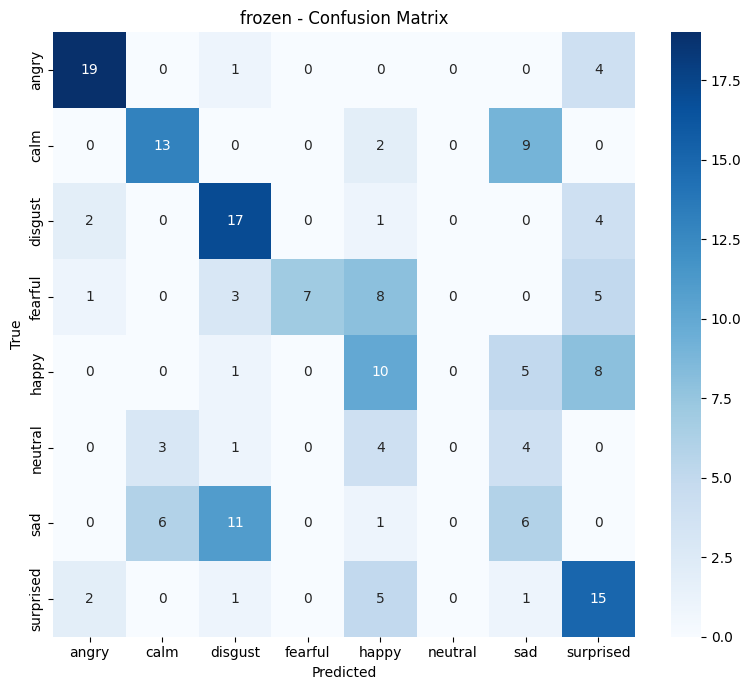

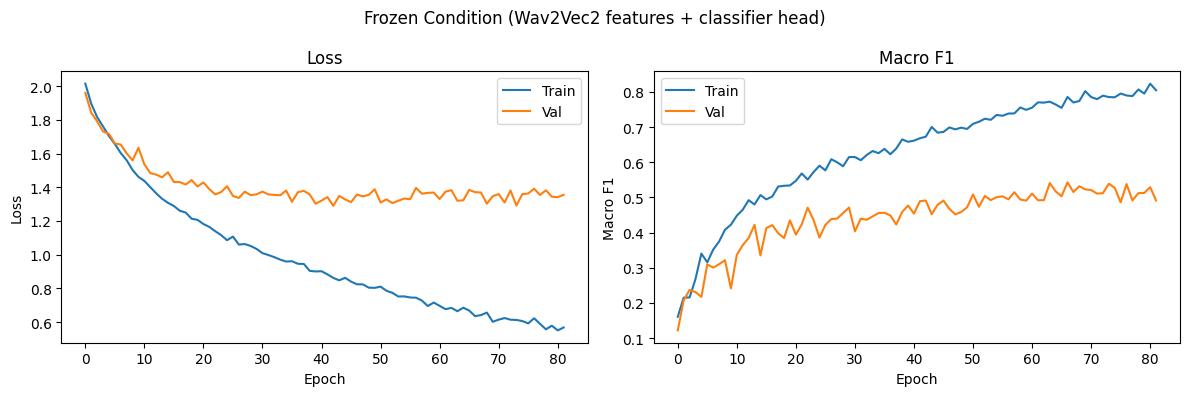

In [9]:
from torch.utils.data import DataLoader


def train_one_epoch_frozen(model, loader, optimizer, criterion):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for embeddings, labels in loader:
        embeddings = embeddings.to(DEVICE)
        labels = torch.as_tensor(labels).to(DEVICE)
        logits = model(embeddings)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * embeddings.size(0)
        all_preds.extend(logits.argmax(-1).detach().cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / len(loader.dataset), f1_score(all_labels, all_preds, average="macro")


@torch.no_grad()
def eval_one_epoch_frozen(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for embeddings, labels in loader:
        embeddings = embeddings.to(DEVICE)
        labels = torch.as_tensor(labels).to(DEVICE)
        logits = model(embeddings)
        loss = criterion(logits, labels)
        total_loss += loss.item() * embeddings.size(0)
        all_preds.extend(logits.argmax(-1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / len(loader.dataset), f1_score(all_labels, all_preds, average="macro")


@torch.no_grad()
def predict_frozen(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for embeddings, labels in loader:
        embeddings = embeddings.to(DEVICE)
        logits = model(embeddings)
        all_preds.extend(logits.argmax(-1).cpu().tolist())
        all_labels.extend(labels.tolist() if torch.is_tensor(labels) else list(labels))
    return np.array(all_labels), np.array(all_preds)


# ── Run training ────────────────────────────────────────────
set_seed(SEED)

train_ds = RAVDESSEmbeddingDataset(cache["train"]["embeddings"], cache["train"]["labels"])
val_ds   = RAVDESSEmbeddingDataset(cache["val"]["embeddings"],   cache["val"]["labels"])
test_ds  = RAVDESSEmbeddingDataset(cache["test"]["embeddings"],  cache["test"]["labels"])

frozen_train_loader = DataLoader(train_ds, batch_size=FROZEN_BATCH_SIZE, shuffle=True)
frozen_val_loader   = DataLoader(val_ds,   batch_size=FROZEN_BATCH_SIZE)
frozen_test_loader  = DataLoader(test_ds,  batch_size=FROZEN_BATCH_SIZE)

frozen_model = EmotionClassifierHead().to(DEVICE)
frozen_optimizer = torch.optim.AdamW(
    frozen_model.parameters(), lr=FROZEN_LR, weight_decay=FROZEN_WEIGHT_DECAY,
)
criterion = nn.CrossEntropyLoss()

frozen_history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
best_val_f1, epochs_no_improve = -1.0, 0
frozen_best_path = os.path.join(CHECKPOINTS_DIR, "frozen_best.pt")

for epoch in range(FROZEN_EPOCHS):
    train_loss, train_f1 = train_one_epoch_frozen(
        frozen_model, frozen_train_loader, frozen_optimizer, criterion)
    val_loss, val_f1 = eval_one_epoch_frozen(
        frozen_model, frozen_val_loader, criterion)

    frozen_history["train_loss"].append(train_loss)
    frozen_history["val_loss"].append(val_loss)
    frozen_history["train_f1"].append(train_f1)
    frozen_history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1:3d} | train loss {train_loss:.4f} f1 {train_f1:.4f} | "
          f"val loss {val_loss:.4f} f1 {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1, epochs_no_improve = val_f1, 0
        torch.save(frozen_model.state_dict(), frozen_best_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= FROZEN_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest val macro F1: {best_val_f1:.4f}")
frozen_model.load_state_dict(torch.load(frozen_best_path))
y_true_frozen, y_pred_frozen = predict_frozen(frozen_model, frozen_test_loader)
frozen_metrics = report(y_true_frozen, y_pred_frozen, condition_name="frozen")

save_training_curves(
    frozen_history,
    os.path.join(RESULTS_DIR, "frozen_curves.png"),
    title="Frozen Condition (Wav2Vec2 features + classifier head)",
)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch   1 | train loss 1.9176 f1 0.2002 | val loss 1.6253 f1 0.3431
Epoch   2 | train loss 1.4069 f1 0.4348 | val loss 1.1992 f1 0.5077
Epoch   3 | train loss 0.8904 f1 0.6610 | val loss 1.0337 f1 0.6391
Epoch   4 | train loss 0.5080 f1 0.8210 | val loss 1.4316 f1 0.6591
Epoch   5 | train loss 0.3676 f1 0.8817 | val loss 1.5924 f1 0.6889
Epoch   6 | train loss 0.2268 f1 0.9318 | val loss 1.5381 f1 0.7470
Epoch   7 | train loss 0.1729 f1 0.9594 | val loss 1.9301 f1 0.6901
Epoch   8 | train loss 0.1135 f1 0.9726 | val loss 1.5512 f1 0.7761
Epoch   9 | train loss 0.0610 f1 0.9844 | val loss 2.0786 f1 0.7400
Epoch  10 | train loss 0.0247 f1 0.9939 | val loss 2.0182 f1 0.7574
Epoch  11 | train loss 0.0042 f1 0.9991 | val loss 2.0886 f1 0.7530
Epoch  12 | train loss 0.0127 f1 0.9965 | val loss 1.9471 f1 0.7794
Epoch  13 | train loss 0.0009 f1 1.0000 | val loss 1.9923 f1 0.7404
Epoch  14 | train loss 0.0071 f1 0.9983 | val loss 1.8876 f1 0.7851
Epoch  15 | train loss 0.0094 f1 0.9974 | val lo

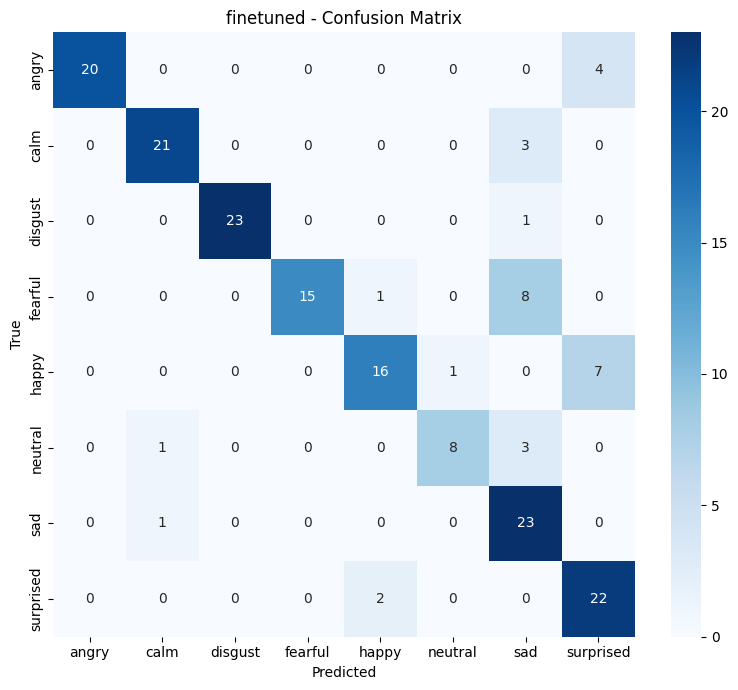

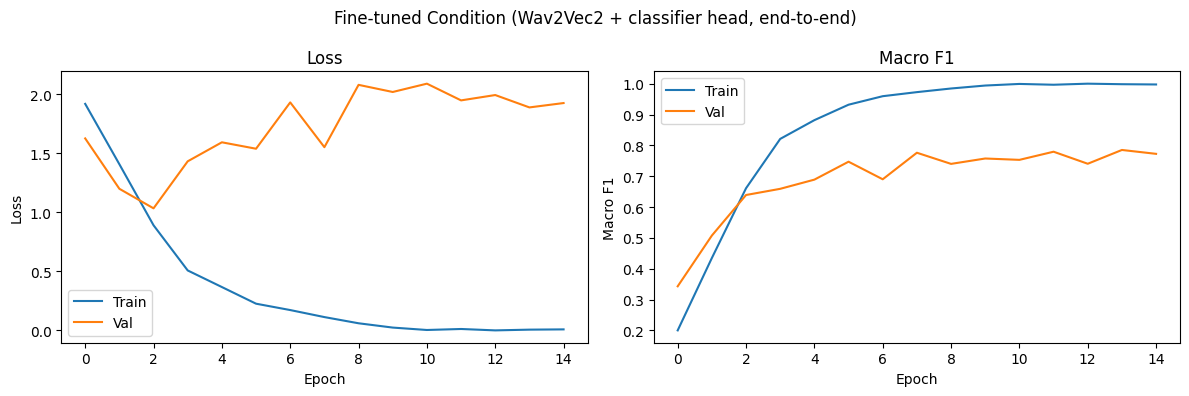

In [10]:
from transformers import get_linear_schedule_with_warmup


def make_collate_fn(feature_extractor):
    """Use Wav2Vec2's feature extractor to normalize and produce attention masks."""
    def collate(batch):
        waveforms = [w.numpy() for w, _ in batch]
        labels = torch.tensor([y for _, y in batch], dtype=torch.long)
        inputs = feature_extractor(
            waveforms,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
            padding=True,
            return_attention_mask=True,
        )
        return inputs, labels
    return collate


def make_optimizer(model):
    """Differential LRs for encoder vs head."""
    encoder_params = [p for p in model.encoder.parameters() if p.requires_grad]
    head_params    = list(model.head.parameters())
    return torch.optim.AdamW(
        [
            {"params": encoder_params, "lr": FT_ENCODER_LR},
            {"params": head_params,    "lr": FT_HEAD_LR},
        ],
        weight_decay=FT_WEIGHT_DECAY,
    )


def train_one_epoch_ft(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for inputs, labels in loader:
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        labels = labels.to(DEVICE)
        logits = model(**inputs)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=FT_GRAD_CLIP)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(-1).detach().cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / len(loader.dataset), f1_score(all_labels, all_preds, average="macro")


@torch.no_grad()
def eval_one_epoch_ft(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for inputs, labels in loader:
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        labels = labels.to(DEVICE)
        logits = model(**inputs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(-1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / len(loader.dataset), f1_score(all_labels, all_preds, average="macro")


@torch.no_grad()
def predict_ft(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for inputs, labels in loader:
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        logits = model(**inputs)
        all_preds.extend(logits.argmax(-1).cpu().tolist())
        all_labels.extend(labels.tolist())
    return np.array(all_labels), np.array(all_preds)


# ── Run training ────────────────────────────────────────────
set_seed(SEED)

ft_feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(PRETRAINED_MODEL)
collate = make_collate_fn(ft_feature_extractor)

ft_train_loader = DataLoader(
    RAVDESSAudioDataset(train_recs),
    batch_size=FT_BATCH_SIZE, shuffle=True,
    collate_fn=collate, num_workers=2,
)
ft_val_loader = DataLoader(
    RAVDESSAudioDataset(val_recs),
    batch_size=FT_BATCH_SIZE, shuffle=False,
    collate_fn=collate, num_workers=2,
)
ft_test_loader = DataLoader(
    RAVDESSAudioDataset(test_recs),
    batch_size=FT_BATCH_SIZE, shuffle=False,
    collate_fn=collate, num_workers=2,
)

ft_model = Wav2Vec2EmotionModel().to(DEVICE)
ft_optimizer = make_optimizer(ft_model)

total_steps  = len(ft_train_loader) * FT_EPOCHS
warmup_steps = int(FT_WARMUP_RATIO * total_steps)
scheduler = get_linear_schedule_with_warmup(
    ft_optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

ft_history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
best_val_f1, epochs_no_improve = -1.0, 0
ft_best_path = os.path.join(CHECKPOINTS_DIR, "finetune_best.pt")

for epoch in range(FT_EPOCHS):
    train_loss, train_f1 = train_one_epoch_ft(
        ft_model, ft_train_loader, ft_optimizer, scheduler, criterion)
    val_loss, val_f1 = eval_one_epoch_ft(ft_model, ft_val_loader, criterion)

    ft_history["train_loss"].append(train_loss)
    ft_history["val_loss"].append(val_loss)
    ft_history["train_f1"].append(train_f1)
    ft_history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1:3d} | train loss {train_loss:.4f} f1 {train_f1:.4f} | "
          f"val loss {val_loss:.4f} f1 {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1, epochs_no_improve = val_f1, 0
        torch.save(ft_model.state_dict(), ft_best_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= FT_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest val macro F1: {best_val_f1:.4f}")
ft_model.load_state_dict(torch.load(ft_best_path))
y_true_ft, y_pred_ft = predict_ft(ft_model, ft_test_loader)
ft_metrics = report(y_true_ft, y_pred_ft, condition_name="finetuned")

save_training_curves(
    ft_history,
    os.path.join(RESULTS_DIR, "finetune_curves.png"),
    title="Fine-tuned Condition (Wav2Vec2 + classifier head, end-to-end)",
)

Final Comparison (test set, speaker-independent)
Metric               Frozen    Fine-tuned         Δ
---------------------------------------------------
accuracy             0.4833        0.8222   +0.3389
macro_f1             0.4367        0.8213   +0.3847
weighted_f1          0.4658        0.8253   +0.3595


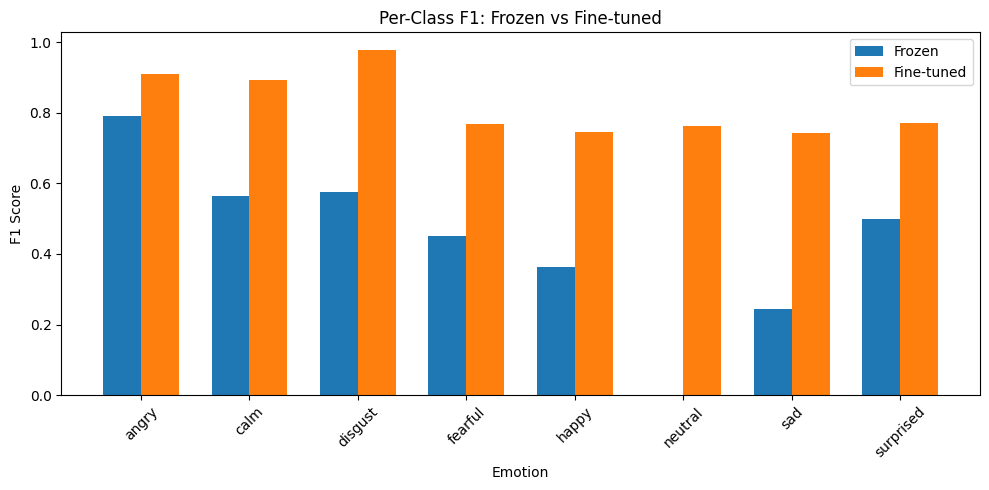

In [11]:
print("=" * 51)
print("Final Comparison (test set, speaker-independent)")
print("=" * 51)
print(f"{'Metric':<15}{'Frozen':>12}{'Fine-tuned':>14}{'Δ':>10}")
print("-" * 51)
for metric in ["accuracy", "macro_f1", "weighted_f1"]:
    f, ft = frozen_metrics[metric], ft_metrics[metric]
    print(f"{metric:<15}{f:>12.4f}{ft:>14.4f}{ft-f:>+10.4f}")
print("=" * 51)

# Per-class F1 bar chart
labels = [IDX_TO_EMOTION[i] for i in sorted(IDX_TO_EMOTION.keys())]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, frozen_metrics["per_class_f1"], width, label="Frozen")
plt.bar(x + width/2, ft_metrics["per_class_f1"],     width, label="Fine-tuned")
plt.xlabel("Emotion"); plt.ylabel("F1 Score")
plt.title("Per-Class F1: Frozen vs Fine-tuned")
plt.xticks(x, labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "comparison.png"), dpi=150)
plt.show()

In [12]:
from google.colab import files
import shutil

# Create a zip of everything in results/ + checkpoints/
shutil.make_archive("ravdess_outputs", "zip", ".", "results")
files.download("ravdess_outputs.zip")
shutil.make_archive("trained_models", "zip", ".", "checkpoints")
files.download("trained_models.zip")
print("Download initiated. Check your browser's Downloads folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated. Check your browser's Downloads folder.


In [15]:
import os
print("Current directory:", os.getcwd())
print()
print("Files here:")
for f in os.listdir("."):
    print(f"  {f}")

Current directory: /content

Files here:
  .config
  ravdess
  trained_models.zip
  checkpoints
  cache
  ravdess_outputs.zip
  results
  sample_data


Converted New Recording 4.m4a to converted.wav
Loaded waveform: torch.Size([64000]), torch.float32


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Predicted emotion: HAPPY (97.3% confidence)

Full probability distribution:
       happy:  97.3%  ██████████████████████████████████████
         sad:   2.7%  █
     disgust:   0.0%  
     fearful:   0.0%  
     neutral:   0.0%  
        calm:   0.0%  
   surprised:   0.0%  
       angry:   0.0%  


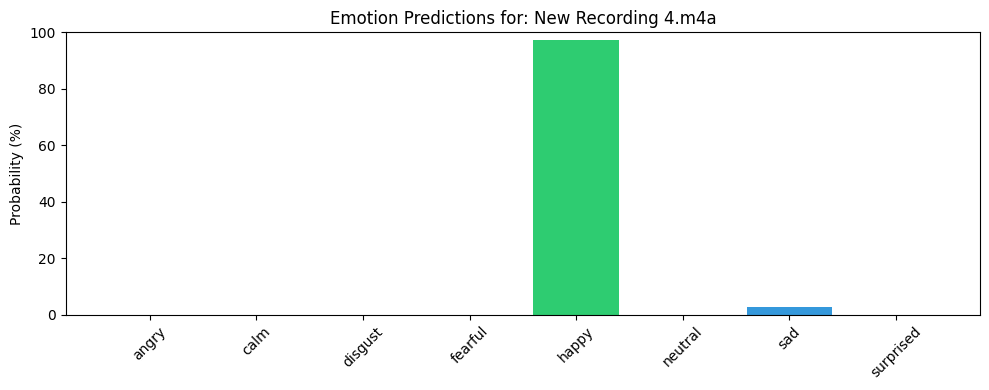

In [16]:
# ============================================================
# Inference on a custom recording
# ============================================================
import subprocess
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# === EDIT THIS LINE: set this to your uploaded file's filename ===
INPUT_FILE = "New Recording 4.m4a"   # whatever you uploaded
# ================================================================

# --- Step 1: Convert to 16 kHz mono WAV using ffmpeg ---
# This handles m4a, mp3, wav, anything iPhone might give you
CONVERTED_FILE = "converted.wav"
subprocess.run([
    "ffmpeg", "-y", "-i", INPUT_FILE,
    "-ac", "1",              # mono
    "-ar", str(SAMPLE_RATE), # 16 kHz
    CONVERTED_FILE,
], check=True, capture_output=True)
print(f"Converted {INPUT_FILE} to {CONVERTED_FILE}")

# --- Step 2: Load and preprocess (reuses your existing function!) ---
waveform = load_and_preprocess_audio(CONVERTED_FILE)
print(f"Loaded waveform: {waveform.shape}, {waveform.dtype}")

# --- Step 3: Choose which model to use ---
# We'll use the fine-tuned model since it's the better of the two.
# To use the frozen model instead, see the alternative cell below.

# Re-instantiate the architecture and load the trained weights
model = Wav2Vec2EmotionModel().to(DEVICE)
model.load_state_dict(torch.load(ft_best_path))
model.eval()

# --- Step 4: Run inference ---
with torch.no_grad():
    # Use the same feature extractor that was used during training
    inputs = ft_feature_extractor(
        waveform.numpy(),
        sampling_rate=SAMPLE_RATE,
        return_tensors="pt",
        return_attention_mask=True,
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    logits = model(**inputs)
    probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

# --- Step 5: Display results ---
predicted_idx = probs.argmax()
predicted_emotion = IDX_TO_EMOTION[predicted_idx]
confidence = probs[predicted_idx]

print(f"\n{'='*45}")
print(f"Predicted emotion: {predicted_emotion.upper()} ({confidence*100:.1f}% confidence)")
print(f"{'='*45}\n")

print("Full probability distribution:")
sorted_indices = probs.argsort()[::-1]  # highest first
for idx in sorted_indices:
    emotion = IDX_TO_EMOTION[idx]
    bar = "█" * int(probs[idx] * 40)
    print(f"  {emotion:>10s}: {probs[idx]*100:5.1f}%  {bar}")

# --- Step 6: Visualize as a bar chart ---
emotions = [IDX_TO_EMOTION[i] for i in sorted(IDX_TO_EMOTION.keys())]
plt.figure(figsize=(10, 4))
colors = ['#2ecc71' if i == predicted_idx else '#3498db' for i in range(len(emotions))]
plt.bar(emotions, probs * 100, color=colors)
plt.ylabel("Probability (%)")
plt.title(f"Emotion Predictions for: {INPUT_FILE}")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Amplitude')

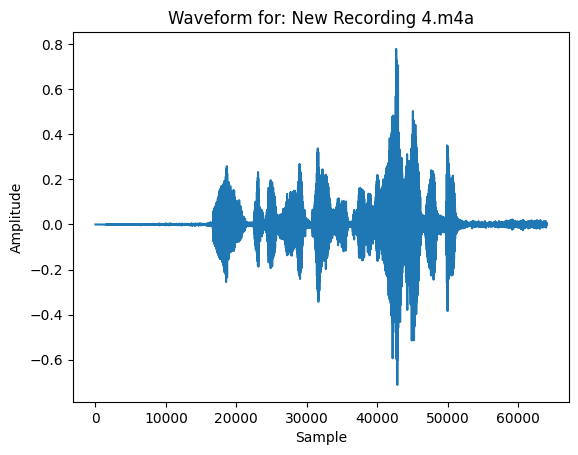

In [17]:
plt.plot(waveform)
plt.title(f"Waveform for: {INPUT_FILE}")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

In [18]:
def predict_emotion(audio_path, model=None, show_plot=True):
    """
    Predict the emotion of an audio file.
    Returns (predicted_emotion, confidence, full_probs_dict).
    """
    # Convert to 16 kHz mono WAV via ffmpeg
    converted = "_temp_converted.wav"
    subprocess.run([
        "ffmpeg", "-y", "-i", audio_path,
        "-ac", "1", "-ar", str(SAMPLE_RATE), converted,
    ], check=True, capture_output=True)

    # Default to the fine-tuned model
    if model is None:
        model = Wav2Vec2EmotionModel().to(DEVICE)
        model.load_state_dict(torch.load(ft_best_path))
        model.eval()

    waveform = load_and_preprocess_audio(converted)

    with torch.no_grad():
        inputs = ft_feature_extractor(
            waveform.numpy(),
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
            return_attention_mask=True,
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        logits = model(**inputs)
        probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()

    predicted_idx = int(probs.argmax())
    predicted_emotion = IDX_TO_EMOTION[predicted_idx]
    confidence = float(probs[predicted_idx])
    probs_dict = {IDX_TO_EMOTION[i]: float(probs[i]) for i in range(len(probs))}

    print(f"→ {predicted_emotion.upper()} ({confidence*100:.1f}%)")

    if show_plot:
        emotions = [IDX_TO_EMOTION[i] for i in sorted(IDX_TO_EMOTION.keys())]
        plt.figure(figsize=(10, 3))
        colors = ['#2ecc71' if i == predicted_idx else '#3498db' for i in range(len(emotions))]
        plt.bar(emotions, probs * 100, color=colors)
        plt.ylabel("Probability (%)")
        plt.title(audio_path)
        plt.xticks(rotation=45)
        plt.ylim(0, 100)
        plt.tight_layout()
        plt.show()

    return predicted_emotion, confidence, probs_dict

In [21]:
# predict_emotion("happy_recording.m4a")
# predict_emotion("angry_recording.m4a")
# predict_emotion("sad_recording.m4a")